In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import sklearn
from sklearn.model_selection import train_test_split

**Banking Domain**

In [ ]:
geo = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Geo_scores.csv')
instance = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/instance_scores.csv')
lmbda = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lambda_wts.csv')
qset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Qset_tats.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test_share.csv')
train = pd.read_csv('/content/drive/MyDrive/train.csv')

In [ ]:
print(geo.shape)

(1424035, 2)


In [ ]:
print(instance.shape)

(1424035, 2)


In [ ]:
print(qset.shape)

(1424035, 2)


In [ ]:
print(lmbda.shape)

(1400, 2)


In [ ]:
print(test.shape)


(56962, 27)


In [ ]:
print(train.shape)


(227845, 28)


In [ ]:
print(geo.info())
print("******************")
print(instance.info())
print("******************")
print(lmbda.info())
print("******************")
print(qset.info())
print("******************")
print(test.info())
print("******************")
print(train.info())
print("******************")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1424035 non-null  int64  
 1   geo_score  1352492 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None
******************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1424035 non-null  int64  
 1   instance_scores  1424035 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None
******************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Group      1400 non-null   object 
 1   lambda_wt  1400 non-null   float64


In [ ]:
print(geo.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1424035 non-null  int64  
 1   geo_score  1352492 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [ ]:
print(instance.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1424035 non-null  int64  
 1   instance_scores  1424035 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [ ]:
print(lmbda.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Group      1400 non-null   object 
 1   lambda_wt  1400 non-null   float64
dtypes: float64(1), object(1)
memory usage: 22.0+ KB
None


In [ ]:
print(qset.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1424035 non-null  int64  
 1   qsets_normalized_tat  1320834 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB
None


In [ ]:
print(test.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56962 entries, 0 to 56961
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              56962 non-null  int64  
 1   Group           56962 non-null  object 
 2   Per1            56962 non-null  float64
 3   Per2            56962 non-null  float64
 4   Per3            56962 non-null  float64
 5   Per4            56962 non-null  float64
 6   Per5            56962 non-null  float64
 7   Per6            56962 non-null  float64
 8   Per7            56962 non-null  float64
 9   Per8            56962 non-null  float64
 10  Per9            56962 non-null  float64
 11  Dem1            56962 non-null  float64
 12  Dem2            56962 non-null  float64
 13  Dem3            56962 non-null  float64
 14  Dem4            56962 non-null  float64
 15  Dem5            56962 non-null  float64
 16  Dem6            56962 non-null  float64
 17  Dem7            56962 non-null 

In [ ]:
print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227845 entries, 0 to 227844
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              227845 non-null  int64  
 1   Group           227845 non-null  object 
 2   Per1            227845 non-null  float64
 3   Per2            227845 non-null  float64
 4   Per3            227845 non-null  float64
 5   Per4            227845 non-null  float64
 6   Per5            227845 non-null  float64
 7   Per6            227845 non-null  float64
 8   Per7            227845 non-null  float64
 9   Per8            227845 non-null  float64
 10  Per9            227845 non-null  float64
 11  Dem1            227845 non-null  float64
 12  Dem2            227845 non-null  float64
 13  Dem3            227845 non-null  float64
 14  Dem4            227845 non-null  float64
 15  Dem5            227845 non-null  float64
 16  Dem6            227845 non-null  float64
 17  Dem7      

# Check Null

In [ ]:
print(geo.isnull().sum())
print("******************")
print(instance.isnull().sum())
print("******************")
print(lmbda.isnull().sum())
print("******************")
print(qset.isnull().sum())
print("******************")
print(test.isnull().sum())
print("******************")
print(train.isnull().sum())
print("******************")

id               0
geo_score    71543
dtype: int64
******************
id                 0
instance_scores    0
dtype: int64
******************
Group        0
lambda_wt    0
dtype: int64
******************
id                           0
qsets_normalized_tat    103201
dtype: int64
******************
id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5              0
Per6              0
Per7              0
Per8              0
Per9              0
Dem1              0
Dem2              0
Dem3              0
Dem4              0
Dem5              0
Dem6              0
Dem7              0
Dem8              0
Dem9              0
Cred1             0
Cred2             0
Cred3             0
Cred4             0
Cred5             0
Cred6             0
Normalised_FNT    0
dtype: int64
******************
id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5    

In [ ]:
print(geo.head(2))
print("******************")
print(instance.head(2))
print("******************")
print(lmbda.head(2))
print("******************")
print(qset.head(2))
print("******************")
print(test.head(2))
print("******************")
print(train.head(2))
print("******************")

       id  geo_score
0   26674       4.48
1  204314       4.48
******************
       id  instance_scores
0  173444            -0.88
1  259378             1.50
******************
    Group  lambda_wt
0  Grp936       3.41
1  Grp347      -2.88
******************
       id  qsets_normalized_tat
0    9983                  2.41
1  266000                  3.10
******************
       id   Group      Per1      Per2  Per3      Per4  Per5      Per6  Per7  \
0  146574  Grp229 -0.300000  1.540000  0.22 -0.280000  0.57  0.260000  0.70   
1  268759  Grp141  0.633333  0.953333  0.81  0.466667  0.91  0.253333  1.04   

       Per8  ...      Dem7      Dem8      Dem9     Cred1     Cred2     Cred3  \
0  1.076667  ...  0.786667  0.546667  0.313333  0.703333  0.813333  0.776667   
1  0.550000  ...  0.636667  0.770000  0.993333  0.536667  0.703333  0.806667   

      Cred4     Cred5     Cred6  Normalised_FNT  
0  0.796667  0.823333  0.783333       -249.7500  
1  0.630000  0.673333  0.673333       -249

In [ ]:
print(geo.head(2))


       id  geo_score
0   26674       4.48
1  204314       4.48


In [ ]:
print(instance.head(2))


       id  instance_scores
0  173444            -0.88
1  259378             1.50


In [ ]:
print(lmbda.head(2))


    Group  lambda_wt
0  Grp936       3.41
1  Grp347      -2.88


In [ ]:
print(qset.head(2))


       id  qsets_normalized_tat
0    9983                  2.41
1  266000                  3.10


In [ ]:
print(test.head(2))


       id   Group      Per1      Per2  Per3      Per4  Per5      Per6  Per7  \
0  146574  Grp229 -0.300000  1.540000  0.22 -0.280000  0.57  0.260000  0.70   
1  268759  Grp141  0.633333  0.953333  0.81  0.466667  0.91  0.253333  1.04   

       Per8  ...      Dem7      Dem8      Dem9     Cred1     Cred2     Cred3  \
0  1.076667  ...  0.786667  0.546667  0.313333  0.703333  0.813333  0.776667   
1  0.550000  ...  0.636667  0.770000  0.993333  0.536667  0.703333  0.806667   

      Cred4     Cred5     Cred6  Normalised_FNT  
0  0.796667  0.823333  0.783333       -249.7500  
1  0.630000  0.673333  0.673333       -249.8125  

[2 rows x 27 columns]


In [ ]:
print(train.head(2))


       id   Group      Per1      Per2      Per3      Per4      Per5      Per6  \
0  112751  Grp169  1.070000  0.580000  0.480000  0.766667  1.233333  1.993333   
1   18495  Grp161  0.473333  1.206667  0.883333  1.430000  0.726667  0.626667   

   Per7      Per8  ...      Dem8      Dem9     Cred1  Cred2     Cred3  \
0  0.34  1.010000  ...  0.680000  0.726667  0.606667   1.01  0.933333   
1  0.81  0.783333  ...  0.716667  0.743333  0.680000   0.69  0.560000   

      Cred4     Cred5     Cred6  Normalised_FNT  Target  
0  0.603333  0.686667  0.673333         -245.75       0  
1  0.670000  0.553333  0.653333         -248.00       0  

[2 rows x 28 columns]


# Check unique no

In [ ]:
print("*******************Unique ID to the customer****************")
print("geo",geo['id'].nunique())
print("******************")
print("instance", instance['id'].nunique())
print("******************")
print("qset",qset['id'].nunique())
print("******************")
print("test", test['id'].nunique())
print("******************")
print("train",train['id'].nunique())

In [ ]:
print("geo",geo['id'].nunique())


geo 284807


In [ ]:
print("instance", instance['id'].nunique())


instance 284807


In [ ]:
print("qset",qset['id'].nunique())


qset 284807


In [ ]:
print("test", test['id'].nunique())


test 56962


In [ ]:
print("train",train['id'].nunique())


train 227845


In [ ]:
print("lmbda",lmbda['Group'].nunique())


lmbda 1400


In [ ]:
print("test",test['Group'].nunique())


test 915


In [ ]:
print("train",train['Group'].nunique())


train 1301


In [ ]:
56962 + 227845

284807

In [ ]:
print(geo.isnull().sum()/len(geo)*100)

id           0.000000
geo_score    5.023964
dtype: float64


In [ ]:
print(qset.isnull().sum()/len(qset)*100)

id                      0.000000
qsets_normalized_tat    7.247083
dtype: float64


In [ ]:
geo

,id,geo_score
0,26674,4.48
1,204314,4.48
2,176521,5.17
3,48812,-2.41
4,126870,6.55
...,...,...
1424030,107880,1.03
1424031,282410,8.62
1424032,209634,-1.72
1424033,211652,-10.00


In [ ]:
instance

,id,instance_scores
0,173444,-0.88
1,259378,1.50
2,161170,0.44
3,191161,0.76
4,34521,-0.84
...,...,...
1424030,80337,0.20
1424031,216371,0.64
1424032,35358,0.77
1424033,159766,10.56


In [ ]:
qset

,id,qsets_normalized_tat
0,9983,2.41
1,266000,3.10
2,77525,1.03
3,160765,-11.63
4,138220,-4.48
...,...,...
1424030,13009,NaN
1424031,147556,-7.24
1424032,143331,10.00
1424033,248231,-7.93


In [ ]:
lmbda

,Group,lambda_wt
0,Grp936,3.41
1,Grp347,-2.88
2,Grp188,0.39
3,Grp1053,-2.75
4,Grp56,-0.83
...,...,...
1395,Grp892,4.24
1396,Grp1072,-7.28
1397,Grp785,-2.63
1398,Grp50,0.79


In [ ]:
test.head(3)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem7,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT
0,146574,Grp229,-0.300000,1.540000,0.22,-0.280000,0.570000,0.260000,0.70,1.076667,...,0.786667,0.546667,0.313333,0.703333,0.813333,0.776667,0.796667,0.823333,0.783333,-249.7500
1,268759,Grp141,0.633333,0.953333,0.81,0.466667,0.910000,0.253333,1.04,0.550000,...,0.636667,0.770000,0.993333,0.536667,0.703333,0.806667,0.630000,0.673333,0.673333,-249.8125
2,59727,Grp188,1.043333,0.740000,0.86,1.006667,0.583333,0.616667,0.63,0.686667,...,0.626667,0.756667,0.953333,0.623333,0.753333,0.870000,0.596667,0.680000,0.670000,-248.1200


In [ ]:
train.head(3)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.680000,0.726667,0.606667,1.010000,0.933333,0.603333,0.686667,0.673333,-245.750,0
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.716667,0.743333,0.680000,0.690000,0.560000,0.670000,0.553333,0.653333,-248.000,0
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.690000,0.820000,0.600000,0.383333,0.763333,0.670000,0.686667,0.673333,-233.125,0


In [ ]:
test.columns

Index(['id', 'Group', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7',
       'Per8', 'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7',
       'Dem8', 'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT'],
      dtype='object')

In [ ]:
print(geo.isnull().sum())
print("******************")
print(instance.isnull().sum())
print("******************")
print(lmbda.isnull().sum())
print("******************")
print(qset.isnull().sum())
print("******************")
print(test.isnull().sum())
print("******************")
print(train.isnull().sum())
print("******************")

In [ ]:
print(train.isnull().sum())


id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5              0
Per6              0
Per7              0
Per8              0
Per9              0
Dem1              0
Dem2              0
Dem3              0
Dem4              0
Dem5              0
Dem6              0
Dem7              0
Dem8              0
Dem9              0
Cred1             0
Cred2             0
Cred3             0
Cred4             0
Cred5             0
Cred6             0
Normalised_FNT    0
Target            0
dtype: int64


In [ ]:
print(test.isnull().sum())


id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5              0
Per6              0
Per7              0
Per8              0
Per9              0
Dem1              0
Dem2              0
Dem3              0
Dem4              0
Dem5              0
Dem6              0
Dem7              0
Dem8              0
Dem9              0
Cred1             0
Cred2             0
Cred3             0
Cred4             0
Cred5             0
Cred6             0
Normalised_FNT    0
dtype: int64


In [ ]:
print(geo.isnull().sum())


id               0
geo_score    71543
dtype: int64


In [ ]:
print(qset.isnull().sum())


id                           0
qsets_normalized_tat    103201
dtype: int64


In [ ]:
print(instance.isnull().sum())


id                 0
instance_scores    0
dtype: int64


In [ ]:
print(lmbda.isnull().sum())


Group        0
lambda_wt    0
dtype: int64


In [ ]:
geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1424035 non-null  int64  
 1   geo_score  1352492 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB


<Axes: ylabel='geo_score'>

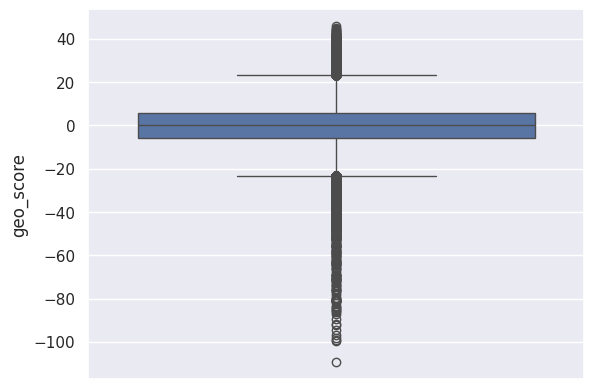

In [ ]:
sns.boxplot(y='geo_score', data=geo)

In [ ]:
qset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424035 entries, 0 to 1424034
Data columns (total 2 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1424035 non-null  int64  
 1   qsets_normalized_tat  1320834 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 21.7 MB


<Axes: ylabel='qsets_normalized_tat'>

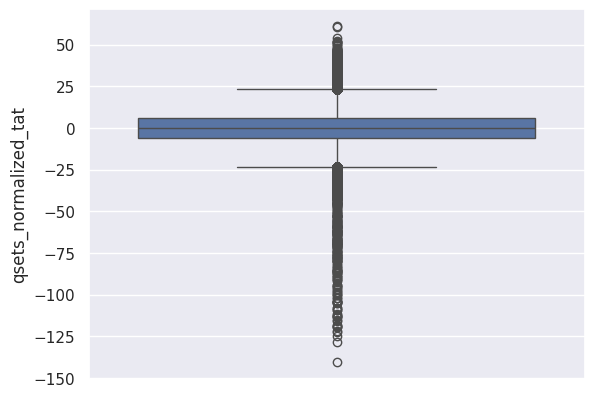

In [ ]:
sns.boxplot(y='qsets_normalized_tat', data=qset)

# fill na with median

In [ ]:
geo['geo_score'] = geo['geo_score'].fillna(geo['geo_score'].median())


In [ ]:
qset['qsets_normalized_tat'] = qset['qsets_normalized_tat'].fillna(qset['qsets_normalized_tat'].median())

In [ ]:
print(geo.isnull().sum()/len(geo)*100)

id           0.0
geo_score    0.0
dtype: float64


In [ ]:
print(qset.isnull().sum()/len(qset)*100)

id                      0.0
qsets_normalized_tat    0.0
dtype: float64


In [ ]:
geo.describe()

,id,geo_score
count,1.424035e+06,1.424035e+06
mean,1.424030e+05,9.034321e-03
std,8.221673e+04,7.628149e+00
min,0.000000e+00,-1.093900e+02
25%,7.120100e+04,-5.170000e+00
50%,1.424030e+05,1.800000e-01
75%,2.136050e+05,5.170000e+00
max,2.848060e+05,4.581000e+01


In [ ]:
test.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem7,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT
0,146574,Grp229,-0.300000,1.540000,0.22,-0.280000,0.57,0.260000,0.70,1.076667,...,0.786667,0.546667,0.313333,0.703333,0.813333,0.776667,0.796667,0.823333,0.783333,-249.7500
1,268759,Grp141,0.633333,0.953333,0.81,0.466667,0.91,0.253333,1.04,0.550000,...,0.636667,0.770000,0.993333,0.536667,0.703333,0.806667,0.630000,0.673333,0.673333,-249.8125


In [ ]:
train.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.680000,0.726667,0.606667,1.01,0.933333,0.603333,0.686667,0.673333,-245.75,0
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.716667,0.743333,0.680000,0.69,0.560000,0.670000,0.553333,0.653333,-248.00,0


In [ ]:
train['Target'].value_counts()

,count
Target,
0,227451
1,394


In [ ]:
# New colmn data is add

train['data'] = 'train'
test['data'] = 'test'

In [ ]:
train.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,data
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,...,0.726667,0.606667,1.01,0.933333,0.603333,0.686667,0.673333,-245.75,0,train
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,...,0.743333,0.680000,0.69,0.560000,0.670000,0.553333,0.653333,-248.00,0,train


In [ ]:
test.head(2)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,data
0,146574,Grp229,-0.300000,1.540000,0.22,-0.280000,0.57,0.260000,0.70,1.076667,...,0.546667,0.313333,0.703333,0.813333,0.776667,0.796667,0.823333,0.783333,-249.7500,test
1,268759,Grp141,0.633333,0.953333,0.81,0.466667,0.91,0.253333,1.04,0.550000,...,0.770000,0.993333,0.536667,0.703333,0.806667,0.630000,0.673333,0.673333,-249.8125,test


In [ ]:
# add both the table together

all_data11 = pd.concat([train, test], axis=0)

In [ ]:
all_data11.shape

(284807, 29)

In [ ]:
print("*******************Unique ID to the customer****************")
print("geo",geo['id'].nunique())
print("******************")
print("instance", instance['id'].nunique())
print("******************")
print("qset",qset['id'].nunique())
print("******************")
print("all_data", all_data['id'].nunique())

*******************Unique ID to the customer****************
geo 284807
******************
instance 284807
******************
qset 284807
******************
all_data 284807


In [ ]:
print("*******************Unique Group to the customer****************")
print("******************")
print("lmbda",lmbda['Group'].nunique())
print("******************")
print("test",test['Group'].nunique())
print("******************")
print("all_data",all_data['Group'].nunique())

*******************Unique Group to the customer****************
******************
lmbda 1400
******************
test 915
******************
all_data 1400


In [ ]:
test.head()

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Dem8,Dem9,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,data
0,146574,Grp229,-0.300000,1.540000,0.220000,-0.280000,0.570000,0.260000,0.700000,1.076667,...,0.546667,0.313333,0.703333,0.813333,0.776667,0.796667,0.823333,0.783333,-249.7500,test
1,268759,Grp141,0.633333,0.953333,0.810000,0.466667,0.910000,0.253333,1.040000,0.550000,...,0.770000,0.993333,0.536667,0.703333,0.806667,0.630000,0.673333,0.673333,-249.8125,test
2,59727,Grp188,1.043333,0.740000,0.860000,1.006667,0.583333,0.616667,0.630000,0.686667,...,0.756667,0.953333,0.623333,0.753333,0.870000,0.596667,0.680000,0.670000,-248.1200,test
3,151544,Grp426,1.283333,0.300000,0.576667,0.636667,0.256667,0.543333,0.356667,0.663333,...,0.460000,0.260000,0.800000,0.606667,0.456667,0.320000,0.676667,0.660000,-222.9875,test
4,155008,Grp443,1.186667,0.326667,0.476667,0.866667,0.436667,0.680000,0.476667,0.686667,...,0.740000,0.823333,0.670000,0.896667,0.566667,0.546667,0.650000,0.663333,-196.2200,test


In [ ]:
lmbda.head()

,Group,lambda_wt
0,Grp936,3.41
1,Grp347,-2.88
2,Grp188,0.39
3,Grp1053,-2.75
4,Grp56,-0.83


In [ ]:
qset.head()

,id,qsets_normalized_tat
0,9983,2.41
1,266000,3.10
2,77525,1.03
3,160765,-11.63
4,138220,-4.48


In [ ]:
instance.shape

(1424035, 2)

In [ ]:
qset.describe()


,id,qsets_normalized_tat
count,1.424035e+06,1.424035e+06
mean,1.424030e+05,1.459564e-03
std,8.221673e+04,7.446362e+00
min,0.000000e+00,-1.404400e+02
25%,7.120100e+04,-5.170000e+00
50%,1.424030e+05,2.000000e-02
75%,2.136050e+05,5.170000e+00
max,2.848060e+05,6.110000e+01


In [ ]:
geo = geo.groupby('id').mean()

In [ ]:
instance = instance.groupby('id').mean()

In [ ]:
qset = qset.groupby('id').mean()

In [ ]:
geo.shape

(284807, 1)

In [ ]:
instance.shape

(284807, 1)

In [ ]:
qset.shape

(284807, 1)

In [ ]:
all_data.shape

(284807, 29)

In [ ]:
lmbda.shape

(1400, 2)

In [ ]:
lmbda.head(2)

,Group,lambda_wt
0,Grp936,3.41
1,Grp347,-2.88


In [ ]:
 all_data  = all_data11

In [ ]:
all_data.shape

(284807, 29)

In [ ]:
all_data = pd.merge(all_data, lmbda, on='Group', how='left')

In [ ]:
all_data.shape

(284807, 30)

In [ ]:
all_data.head()

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred1,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.606667,1.010000,0.933333,0.603333,0.686667,0.673333,-245.7500,0.0,train,-0.13
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.680000,0.690000,0.560000,0.670000,0.553333,0.653333,-248.0000,0.0,train,0.66
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.600000,0.383333,0.763333,0.670000,0.686667,0.673333,-233.1250,0.0,train,-0.51
3,50806,Grp198,0.636667,1.090000,0.750000,0.940000,0.743333,0.346667,0.956667,0.633333,...,0.680000,0.846667,0.423333,0.520000,0.846667,0.760000,-249.7775,0.0,train,0.72
4,184244,Grp228,0.560000,1.013333,0.593333,0.416667,0.773333,0.460000,0.853333,0.796667,...,0.693333,0.526667,0.520000,0.716667,0.706667,0.673333,-247.5775,0.0,train,0.60


In [ ]:
all_data = pd.merge(all_data, geo, on='id', how='left')


In [ ]:
all_data.shape

(284807, 31)

In [ ]:
all_data.head(3)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt,geo_score
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,1.010000,0.933333,0.603333,0.686667,0.673333,-245.750,0.0,train,-0.13,0.256
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.690000,0.560000,0.670000,0.553333,0.653333,-248.000,0.0,train,0.66,-0.250
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.383333,0.763333,0.670000,0.686667,0.673333,-233.125,0.0,train,-0.51,-0.950


In [ ]:
all_data = pd.merge(all_data, instance, on='id', how='left')


In [ ]:
all_data.head()

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt,geo_score,instance_scores
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.933333,0.603333,0.686667,0.673333,-245.7500,0.0,train,-0.13,0.256,-0.06
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.560000,0.670000,0.553333,0.653333,-248.0000,0.0,train,0.66,-0.250,0.52
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.763333,0.670000,0.686667,0.673333,-233.1250,0.0,train,-0.51,-0.950,1.56
3,50806,Grp198,0.636667,1.090000,0.750000,0.940000,0.743333,0.346667,0.956667,0.633333,...,0.423333,0.520000,0.846667,0.760000,-249.7775,0.0,train,0.72,0.490,0.70
4,184244,Grp228,0.560000,1.013333,0.593333,0.416667,0.773333,0.460000,0.853333,0.796667,...,0.520000,0.716667,0.706667,0.673333,-247.5775,0.0,train,0.60,0.850,-0.47


In [ ]:
all_data.shape

(284807, 32)

In [ ]:
all_data = pd.merge(all_data, qset, on='id', how='left')

In [ ]:
all_data.shape

(284807, 33)

In [ ]:
all_data['Group'].nunique()

1400

In [ ]:
lmbda['Group'].nunique()

1400

In [ ]:
all_data.head(3)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.603333,0.686667,0.673333,-245.750,0.0,train,-0.13,0.256,-0.06,-0.70
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.670000,0.553333,0.653333,-248.000,0.0,train,0.66,-0.250,0.52,0.14
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.670000,0.686667,0.673333,-233.125,0.0,train,-0.51,-0.950,1.56,-0.43


In [ ]:
train = all_data[all_data['data']=='train']

test = all_data[all_data['data']=='test']

In [ ]:
train.shape

(227845, 33)

In [ ]:
test.shape

(56962, 33)

In [ ]:
test.columns

Index(['id', 'Group', 'Per1', 'Per2', 'Per3', 'Per4', 'Per5', 'Per6', 'Per7',
       'Per8', 'Per9', 'Dem1', 'Dem2', 'Dem3', 'Dem4', 'Dem5', 'Dem6', 'Dem7',
       'Dem8', 'Dem9', 'Cred1', 'Cred2', 'Cred3', 'Cred4', 'Cred5', 'Cred6',
       'Normalised_FNT', 'Target', 'data', 'lambda_wt', 'geo_score',
       'instance_scores', 'qsets_normalized_tat'],
      dtype='object')

In [ ]:
test.head(3)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
227845,146574,Grp229,-0.300000,1.540000,0.22,-0.280000,0.570000,0.260000,0.70,1.076667,...,0.796667,0.823333,0.783333,-249.7500,NaN,test,0.76,0.25,-0.04,-0.426
227846,268759,Grp141,0.633333,0.953333,0.81,0.466667,0.910000,0.253333,1.04,0.550000,...,0.630000,0.673333,0.673333,-249.8125,NaN,test,0.18,0.43,-0.77,-0.620
227847,59727,Grp188,1.043333,0.740000,0.86,1.006667,0.583333,0.616667,0.63,0.686667,...,0.596667,0.680000,0.670000,-248.1200,NaN,test,0.39,1.32,0.11,-0.406


In [ ]:
train.head(3)

,id,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,...,Cred4,Cred5,Cred6,Normalised_FNT,Target,data,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
0,112751,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.340000,1.010000,...,0.603333,0.686667,0.673333,-245.750,0.0,train,-0.13,0.256,-0.06,-0.70
1,18495,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.810000,0.783333,...,0.670000,0.553333,0.653333,-248.000,0.0,train,0.66,-0.250,0.52,0.14
2,23915,Grp261,1.130000,0.143333,0.946667,0.123333,0.080000,0.836667,0.056667,0.756667,...,0.670000,0.686667,0.673333,-233.125,0.0,train,-0.51,-0.950,1.56,-0.43


In [ ]:
train = train.drop(['id', 'data'], axis=1)           # Building a model

test = test.drop(['id', 'data'], axis=1)            # Prediction and final result

In [ ]:
train.head(2)

,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,Per9,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
0,Grp169,1.070000,0.580000,0.480000,0.766667,1.233333,1.993333,0.34,1.010000,0.863333,...,0.933333,0.603333,0.686667,0.673333,-245.75,0.0,-0.13,0.256,-0.06,-0.70
1,Grp161,0.473333,1.206667,0.883333,1.430000,0.726667,0.626667,0.81,0.783333,0.190000,...,0.560000,0.670000,0.553333,0.653333,-248.00,0.0,0.66,-0.250,0.52,0.14


In [ ]:
test.head(2)

,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,Per9,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,Target,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
227845,Grp229,-0.300000,1.540000,0.22,-0.280000,0.57,0.260000,0.70,1.076667,0.930000,...,0.776667,0.796667,0.823333,0.783333,-249.7500,NaN,0.76,0.25,-0.04,-0.426
227846,Grp141,0.633333,0.953333,0.81,0.466667,0.91,0.253333,1.04,0.550000,0.543333,...,0.806667,0.630000,0.673333,0.673333,-249.8125,NaN,0.18,0.43,-0.77,-0.620


In [ ]:
test = test.drop(['Target'], axis=1)

In [ ]:
test.head(2)

,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,Per9,...,Cred2,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,lambda_wt,geo_score,instance_scores,qsets_normalized_tat
227845,Grp229,-0.300000,1.540000,0.22,-0.280000,0.57,0.260000,0.70,1.076667,0.930000,...,0.813333,0.776667,0.796667,0.823333,0.783333,-249.7500,0.76,0.25,-0.04,-0.426
227846,Grp141,0.633333,0.953333,0.81,0.466667,0.91,0.253333,1.04,0.550000,0.543333,...,0.703333,0.806667,0.630000,0.673333,0.673333,-249.8125,0.18,0.43,-0.77,-0.620


In [ ]:
unseen_test_data = test.copy()

In [ ]:
unseen_test_data['Group'] = unseen_test_data['Group'].astype('category')

In [ ]:
unseen_test_data['Group'] = unseen_test_data['Group'].cat.codes         # converting text to numbers quickly

In [ ]:
unseen_test_data['Group']

,Group
227845,277
227846,180
227847,231
227848,485
227849,504
...,...
284802,11
284803,569
284804,765
284805,163


In [ ]:
# Difference between .cat.codes and LabelEncoder

In [ ]:
train.isnull().sum()

,0
Group,0
Per1,0
Per2,0
Per3,0
Per4,0
Per5,0
Per6,0
Per7,0
Per8,0
Per9,0


In [ ]:
train['Group'] = train['Group'].astype('category')

train['Group'] = train['Group'].cat.codes

In [ ]:
train['Group']

,Group
0,420
1,413
2,523
3,452
4,486
...,...
227840,491
227841,453
227842,632
227843,727


In [ ]:
# split the data into ind and dep variable

x = train.drop(['Target'], axis=1)

y= train['Target']

In [ ]:
y.value_counts(normalize = True)*100

,proportion
Target,
0.0,99.827075
1.0,0.172925


In [ ]:
train['Target'].value_counts()

,count
Target,
0.0,227451
1.0,394


In [ ]:
227451-394

227057

In [ ]:
# split the data into training and testing
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=101,stratify=y)

In [ ]:
y_train.value_counts()

,count
Target,
0.0,181961
1.0,315


In [ ]:
y_test.value_counts()

,count
Target,
0.0,45490
1.0,79


In [ ]:
y_train.value_counts(normalize=True)*100

,proportion
Target,
0.0,99.827185
1.0,0.172815


In [ ]:
y_test.value_counts(normalize=True)*100

,proportion
Target,
0.0,99.826637
1.0,0.173363


In [ ]:
# Building Model

from sklearn.ensemble import RandomForestClassifier

rfmodel = RandomForestClassifier()
rfmodel.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred_train = rfmodel.predict(x_train)

In [ ]:
y_pred_test = rfmodel.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
print(classification_report(y_train, y_pred_train))
print("*****************")
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    181961
         1.0       1.00      1.00      1.00       315

    accuracy                           1.00    182276
   macro avg       1.00      1.00      1.00    182276
weighted avg       1.00      1.00      1.00    182276

*****************
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     45490
         1.0       0.97      0.71      0.82        79

    accuracy                           1.00     45569
   macro avg       0.98      0.85      0.91     45569
weighted avg       1.00      1.00      1.00     45569



In [ ]:
print(accuracy_score(y_train, y_pred_train))
print("*****************")
print(accuracy_score(y_test, y_pred_test))

1.0
*****************
0.9994513814215804


In [ ]:
# please do cross validation with train dataset

In [ ]:
final_output = rfmodel.predict(unseen_test_data)

In [ ]:
final_output

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
final_output = pd.DataFrame(final_output)
final_output.columns


RangeIndex(start=0, stop=1, step=1)

In [ ]:
unseen_test_data.shape

(56962, 30)

In [ ]:
final_output.shape

(56962, 1)

In [ ]:
final_output.to_csv("Final_Target_Value.csv")

In [ ]:
final_output.value_counts()

,count
0,
0.0,56881
1.0,81


In [ ]:
final_output_prediction = pd.concat([unseen_test_data, final_output],axis=1)

In [ ]:
final_output_prediction.head(5)

,Group,Per1,Per2,Per3,Per4,Per5,Per6,Per7,Per8,Per9,...,Cred3,Cred4,Cred5,Cred6,Normalised_FNT,lambda_wt,geo_score,instance_scores,qsets_normalized_tat,0
227845,277.0,-0.300000,1.540000,0.220000,-0.280000,0.570000,0.260000,0.700000,1.076667,0.930000,...,0.776667,0.796667,0.823333,0.783333,-249.7500,0.76,0.25,-0.04,-0.426,NaN
227846,180.0,0.633333,0.953333,0.810000,0.466667,0.910000,0.253333,1.040000,0.550000,0.543333,...,0.806667,0.630000,0.673333,0.673333,-249.8125,0.18,0.43,-0.77,-0.620,NaN
227847,231.0,1.043333,0.740000,0.860000,1.006667,0.583333,0.616667,0.630000,0.686667,0.593333,...,0.870000,0.596667,0.680000,0.670000,-248.1200,0.39,1.32,0.11,-0.406,NaN
227848,485.0,1.283333,0.300000,0.576667,0.636667,0.256667,0.543333,0.356667,0.663333,1.156667,...,0.456667,0.320000,0.676667,0.660000,-222.9875,1.80,-2.11,0.33,0.374,NaN
227849,504.0,1.186667,0.326667,0.476667,0.866667,0.436667,0.680000,0.476667,0.686667,1.476667,...,0.566667,0.546667,0.650000,0.663333,-196.2200,1.89,-2.11,-0.37,-0.130,NaN


In [ ]:
# rashmi5kausar@gmail.com,,a3a